# Bike analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


In [13]:
trip_data = pd.read_csv("/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/sjovik_sund_alphas_081225_TD_alpha03_D5h_0.300_results_trip_requests_seed_1.csv")

#print account of trips per bike and their assosicated criticality for each trip
bike_trip_counts = trip_data['Bike ID'].value_counts()
print("Trip counts per bike:")
print(bike_trip_counts)
bike_criticality = trip_data.groupby('Bike ID')['Bike Criticality']
print("\nAverage criticality per bike:")
print(bike_criticality)

Trip counts per bike:
Bike ID
B232    4
B104    4
B105    4
B610    4
B124    4
       ..
B184    1
B411    1
B331    1
B272    1
B428    1
Name: count, Length: 518, dtype: int64

Average criticality per bike:


In [15]:
# Check what columns are in the trip data
print("Available columns in trip_data:")
print(trip_data.columns.tolist())
print("\nFirst few rows:")
print(trip_data.head())

Available columns in trip_data:
['Seed', 'Alpha', 'Day', 'Hour', 'Minute', 'Time (minutes)', 'Station ID', 'Success', 'Failure Reason', 'Did Roam', 'Arrival Station ID', 'Travel Time (minutes)', 'Bike ID', 'Bike Criticality']

First few rows:
   Seed  Alpha  Day  Hour  Minute  Time (minutes) Station ID  Success  \
0     1    0.3    0     7       0             420         S2     True   
1     1    0.3    0     7       0             420        S51     True   
2     1    0.3    0     7       1             421        S64     True   
3     1    0.3    0     7       2             422        S22     True   
4     1    0.3    0     7       2             422        S28     True   

  Failure Reason  Did Roam Arrival Station ID  Travel Time (minutes) Bike ID  \
0            NaN     False                 S7                  11.68     B17   
1            NaN     False                S52                   8.58    B572   
2            NaN     False                S54                  20.59    B737  


Trip data for Bike ID B104:
     Day  Hour  Minute  Time (minutes) Station ID Arrival Station ID  \
138    0     7      55             475        S11                S35   
256    0     8      50             530        S35                S29   
468    0    10      12             612        S29                S50   
775    0    11      45             705        S50                S11   

     Bike Criticality  
138            0.6435  
256            0.6435  
468            0.6435  
775            0.6435  


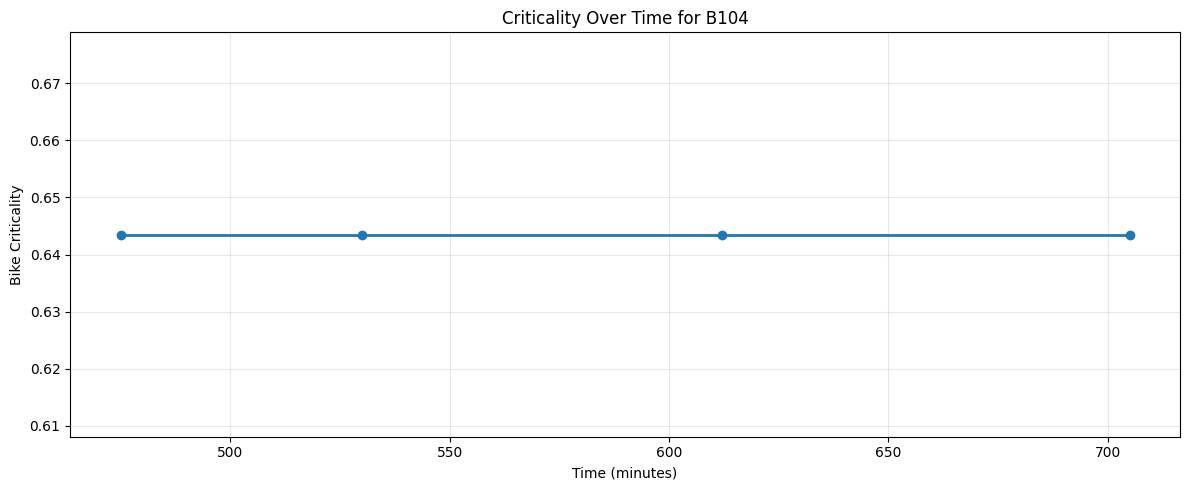


Criticality Statistics for B104:
Mean: 0.6435
Min: 0.6435
Max: 0.6435
Std: 0.0000


In [16]:
# Analyze how criticality changed over time for a specific bike
bike_id = "B104"
bike_data = trip_data[trip_data['Bike ID'] == bike_id].copy()
bike_data = bike_data.sort_values('Time (minutes)')

print(f"\nTrip data for Bike ID {bike_id}:")
print(bike_data[['Day', 'Hour', 'Minute', 'Time (minutes)', 'Station ID', 'Arrival Station ID', 'Bike Criticality']])

# Plot criticality over time
plt.figure(figsize=(12, 5))
plt.plot(bike_data['Time (minutes)'], bike_data['Bike Criticality'], marker='o', linestyle='-', linewidth=2)
plt.xlabel('Time (minutes)')
plt.ylabel('Bike Criticality')
plt.title(f'Criticality Over Time for {bike_id}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCriticality Statistics for {bike_id}:")
print(f"Mean: {bike_data['Bike Criticality'].mean():.4f}")
print(f"Min: {bike_data['Bike Criticality'].min():.4f}")
print(f"Max: {bike_data['Bike Criticality'].max():.4f}")
print(f"Std: {bike_data['Bike Criticality'].std():.4f}")

Bikes with most criticality variation (top 10):
              std  count      mean
Bike ID                           
B161     0.534926      2  0.491550
B29      0.520572      2  0.489900
B583     0.409627      2  0.471450
B308     0.317420      2  0.445550
B516     0.304090      3  0.374567
B491     0.298952      3  0.374400
B640     0.276903      2  0.430000
B453     0.251730      2  0.418700
B624     0.236021      3  0.326467
B724     0.222244      2  0.403450


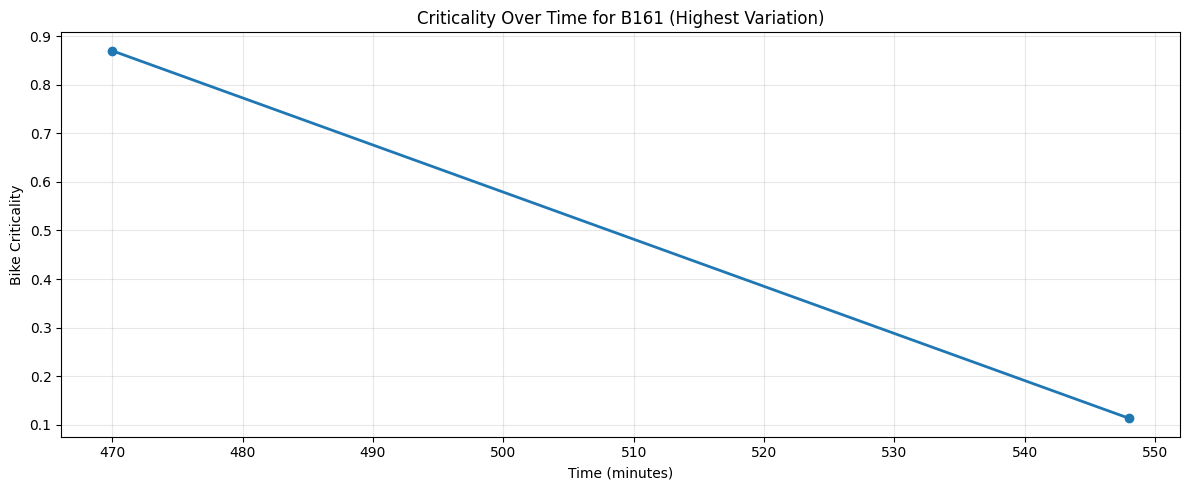

In [17]:
# Find bikes with varying criticality
bike_criticality_variance = trip_data.groupby('Bike ID')['Bike Criticality'].agg(['std', 'count', 'mean'])
bike_criticality_variance = bike_criticality_variance[bike_criticality_variance['count'] > 1]
bike_criticality_variance = bike_criticality_variance.sort_values('std', ascending=False)

print("Bikes with most criticality variation (top 10):")
print(bike_criticality_variance.head(10))

# Plot a bike with high variation
if len(bike_criticality_variance) > 0 and bike_criticality_variance.iloc[0]['std'] > 0:
    most_varying_bike = bike_criticality_variance.index[0]
    varying_bike_data = trip_data[trip_data['Bike ID'] == most_varying_bike].copy()
    varying_bike_data = varying_bike_data.sort_values('Time (minutes)')
    
    plt.figure(figsize=(12, 5))
    plt.plot(varying_bike_data['Time (minutes)'], varying_bike_data['Bike Criticality'], marker='o', linestyle='-', linewidth=2)
    plt.xlabel('Time (minutes)')
    plt.ylabel('Bike Criticality')
    plt.title(f'Criticality Over Time for {most_varying_bike} (Highest Variation)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo bikes show criticality variation - all criticalities appear to be static.")

In [18]:
# Find bikes with direction changes in criticality (up -> down -> up pattern)
def count_direction_changes(criticality_values):
    """Count how many times criticality changes direction (increasing to decreasing or vice versa)"""
    if len(criticality_values) < 3:
        return 0
    
    changes = 0
    prev_direction = None
    
    for i in range(1, len(criticality_values)):
        diff = criticality_values[i] - criticality_values[i-1]
        
        if diff > 0.0001:  # Going up (with small tolerance for floating point)
            current_direction = 'up'
        elif diff < -0.0001:  # Going down
            current_direction = 'down'
        else:  # No change
            continue
            
        if prev_direction is not None and current_direction != prev_direction:
            changes += 1
            
        prev_direction = current_direction
    
    return changes

# Analyze direction changes for each bike
bike_direction_changes = []

for bike_id in trip_data['Bike ID'].unique():
    bike_trips = trip_data[trip_data['Bike ID'] == bike_id].sort_values('Time (minutes)')
    criticalities = bike_trips['Bike Criticality'].values
    
    if len(criticalities) >= 3:
        num_changes = count_direction_changes(criticalities)
        if num_changes >= 2:  # At least 2 direction changes (e.g., up->down->up)
            bike_direction_changes.append({
                'Bike ID': bike_id,
                'Direction Changes': num_changes,
                'Num Trips': len(criticalities),
                'Criticality Range': f"{criticalities.min():.4f} - {criticalities.max():.4f}",
                'Criticalities': criticalities.tolist()
            })

# Sort by number of direction changes
bike_direction_changes.sort(key=lambda x: x['Direction Changes'], reverse=True)

print(f"Bikes with at least 2 direction changes (e.g., up->down->up pattern):")
print(f"Found {len(bike_direction_changes)} bikes with this pattern\n")

if len(bike_direction_changes) > 0:
    for i, bike_info in enumerate(bike_direction_changes[:10]):  # Show top 10
        print(f"{i+1}. {bike_info['Bike ID']}: {bike_info['Direction Changes']} changes, "
              f"{bike_info['Num Trips']} trips, range: {bike_info['Criticality Range']}")
        print(f"   Criticality sequence: {[f'{c:.4f}' for c in bike_info['Criticalities']]}")
    
    # Plot the first bike with direction changes
    print(f"\nPlotting criticality pattern for {bike_direction_changes[0]['Bike ID']}:")
    
    bike_id = bike_direction_changes[0]['Bike ID']
    bike_trips = trip_data[trip_data['Bike ID'] == bike_id].sort_values('Time (minutes)')
    
    plt.figure(figsize=(14, 6))
    plt.plot(bike_trips['Time (minutes)'], bike_trips['Bike Criticality'], 
             marker='o', linestyle='-', linewidth=2, markersize=8)
    
    # Annotate each point with its value
    for idx, row in bike_trips.iterrows():
        plt.annotate(f'{row["Bike Criticality"]:.4f}', 
                    xy=(row['Time (minutes)'], row['Bike Criticality']),
                    xytext=(0, 10), textcoords='offset points', 
                    ha='center', fontsize=9)
    
    plt.xlabel('Time (minutes)')
    plt.ylabel('Bike Criticality')
    plt.title(f'Criticality Pattern for {bike_id} ({bike_direction_changes[0]["Direction Changes"]} direction changes)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No bikes found with direction changes in criticality.")

Bikes with at least 2 direction changes (e.g., up->down->up pattern):
Found 0 bikes with this pattern

No bikes found with direction changes in criticality.
